# Embeddings and Chunking with LlamaIndex and Gemini

In this notebook, we explore different chunking techniques and embedding models in LlamaIndex while using Google's Gemini for our language model. We'll learn how different chunking strategies affect retrieval performance and how to use various embedding models.

## Setup and Installation

First, let's install the necessary packages:

In [1]:
# ============================================
# STEP 0: Install Required Libraries
# ============================================
#
# WHAT WE'RE DOING: Installing all the libraries we need for embeddings, chunking, and search.
# WHY THIS MATTERS: Each library handles a different piece of our AI search system.
# WHAT YOU'LL SEE: Download progress bars. This may take a few minutes — be patient!
#
# TROUBLESHOOTING: If you see errors, try running this cell again.
# Some packages may already be installed, which is fine.
# ============================================
!pip install -q llama-index
!pip install -q llama-index-embeddings-huggingface
!pip install -q llama-index-llms-gemini
!pip install -q llama-index-embeddings-openai
!pip install -q llama-index-vector-stores-chroma
!pip install -q sentence-transformers
!pip install -q chromadb
!pip install -q scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.5/164.5 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cpu requires setuptools<82, but you have setuptools 83.0.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour

Now let's set up our environment:

In [2]:
# ============================================
# STEP 1a: Import Python Libraries
# ============================================
#
# WHAT WE'RE DOING: Loading the Python tools we'll use throughout this notebook.
# WHY THIS MATTERS: Each import gives us access to specific functionality.
# WHAT YOU'LL SEE: No output — imports are silent unless there's an error.
# ============================================
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [ ]:
# ============================================
# STEP 1: Set Up Your API Key
# ============================================
#
# WHAT WE'RE DOING:
# Setting our Google API key so we can use Gemini later for AI-powered queries.
#
# WHY THIS MATTERS:
# The API key is like a password that lets our code talk to Google's AI.
#
# WHAT YOU'LL SEE:
# No output — the key is saved silently.
#
# TROUBLESHOOTING:
# - Get your free API key at: https://aistudio.google.com/app/apikey
# - Make sure there are no extra spaces around your key
# ============================================
GOOGLE_API_KEY = "YOUR_API_KEY_HERE"  # Replace with your actual API key
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

if GOOGLE_API_KEY == "YOUR_API_KEY_HERE":
    print("⚠️ WARNING: Please replace YOUR_API_KEY_HERE with your actual API key!")
    print("Get one free at: https://aistudio.google.com/app/apikey")

## 1. Loading Sample Documents

We'll create a small sample of documents to work with. First, let's create a directory and some sample files:

In [4]:
# Create a folder to store our sample documents
!mkdir -p sample_docs

In [5]:
# ============================================
# STEP 2: Create Sample Documents
# ============================================
#
# WHAT WE'RE DOING: Creating 3 sample text files about AI topics.
# These will be the "documents" our AI will search through.
# WHY THIS MATTERS: In the real world, these would be pharmaceutical documents,
# research papers, or quality reports. We use simple AI text for practice.
# WHAT YOU'LL SEE: No output — the files are created silently in the sample_docs folder.
# ============================================

# Let's create some example documents
with open("sample_docs/ai_history.txt", "w") as f:
    f.write("""Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.
The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.
These models are trained on vast amounts of text data and can generate human-like responses.""")

with open("sample_docs/neural_networks.txt", "w") as f:
    f.write("""Neural networks are computing systems inspired by biological neural networks.
The perceptron, developed by Frank Rosenblatt in 1958, was one of the earliest neural network models.
Modern neural networks consist of layers of interconnected nodes or "neurons."
Each connection can transmit a signal from one neuron to another.
The receiving neuron processes the signal and signals downstream neurons connected to it.
Deep neural networks contain multiple hidden layers between input and output layers.
Convolutional Neural Networks (CNNs) revolutionized image processing.
Recurrent Neural Networks (RNNs) and transformers handle sequential data like text or time series.""")

with open("sample_docs/embeddings.txt", "w") as f:
    f.write("""Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar words are positioned closer together.
Popular word embedding techniques include Word2Vec, GloVe, and FastText.
Sentence embeddings capture meaning at the sentence level rather than individual words.
Models like Universal Sentence Encoder and SBERT create powerful sentence embeddings.
Document embeddings represent entire documents as fixed-length vectors.
Embeddings enable semantic search by finding documents with similar meaning, not just keyword matches.
They also power recommendation systems, clustering, and classification tasks.
Recent models like OpenAI's text-embedding-ada and Cohere's embedding models offer state-of-the-art performance.""")

Now let's load these documents using LlamaIndex:

In [6]:
# ============================================
# STEP 3: Load Documents
# ============================================
#
# WHAT WE'RE DOING: Loading all our sample documents using LlamaIndex's SimpleDirectoryReader.
# WHY THIS MATTERS: This is the first step in any RAG pipeline — getting your documents into the system.
# WHAT YOU'LL SEE: A count of how many documents were loaded, plus a preview of each one.
# ============================================
from llama_index.core import SimpleDirectoryReader

# Load documents
documents = SimpleDirectoryReader("sample_docs").load_data()
print(f"Loaded {len(documents)} documents.")

# Display document contents
for i, doc in enumerate(documents):
    print(f"\n--- Document {i+1}: {doc.metadata['file_name']} ---")
    print(doc.text[:200] + "...")  # Show first 200 chars

Loaded 3 documents.

--- Document 1: ai_history.txt ---
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods ...

--- Document 2: embeddings.txt ---
Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar words are positioned closer together.
Popular word embedding techni...

--- Document 3: neural_networks.txt ---
Neural networks are computing systems inspired by biological neural networks.
The perceptron, developed by Frank Rosenblatt in 1958, was one of the earliest neural network models.
Modern neural networ...


## 2. Exploring Different Chunking Techniques

Chunking is a critical preprocessing step for using documents with LLMs. Let's explore different chunking strategies:



### 2.1 Fixed-Length Chunking

The simplest approach is to divide text into chunks of a fixed size:

In [7]:
# ============================================
# STEP 4: Fixed-Length Chunking
# ============================================
#
# WHAT WE'RE DOING: Breaking our documents into fixed-size chunks (100 tokens each, no overlap).
# WHY THIS MATTERS: AI can't process huge documents at once — chunking breaks them into manageable pieces.
# WHAT YOU'LL SEE: The total number of chunks created, plus a sample chunk.
# ============================================
from llama_index.core.node_parser import SentenceSplitter

# Fixed-length chunking with no overlap
splitter_fixed = SentenceSplitter(chunk_size=100, chunk_overlap=0)
chunks_fixed = splitter_fixed.get_nodes_from_documents(documents)
print(f"Total Fixed-Length Chunks Created: {len(chunks_fixed)}")

# Display a sample chunk
print(f"\nSample fixed-length chunk:")
print(chunks_fixed[0].text)

Total Fixed-Length Chunks Created: 6

Sample fixed-length chunk:
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.
The 1990s and early 2000s saw a shift towards machine learning approaches.


### 2.2 Overlapping Chunks

Adding overlap between chunks helps maintain context across chunk boundaries:

In [8]:
# ============================================
# STEP 5: Overlapping Chunks
# ============================================
#
# WHAT WE'RE DOING: Creating chunks with 20-token overlap between consecutive chunks.
# WHY THIS MATTERS: Overlap prevents important context from being lost at chunk boundaries.
# WHAT YOU'LL SEE: Chunk count and an example showing how two chunks share overlapping text.
# ============================================

# Chunking with overlap
splitter_overlap = SentenceSplitter(chunk_size=100, chunk_overlap=20)
chunks_overlap = splitter_overlap.get_nodes_from_documents(documents)
print(f"Total Overlapping Chunks Created: {len(chunks_overlap)}")

# Display a sample chunk with its neighbor to see overlap
print(f"\nOverlap Example:")
print(f"Chunk 1: {chunks_overlap[0].text}")
print(f"Chunk 2: {chunks_overlap[1].text}")

Total Overlapping Chunks Created: 6

Overlap Example:
Chunk 1: Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.
The 1990s and early 2000s saw a shift towards machine learning approaches.
Chunk 2: The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.
These models are trained on vast amounts of text data and can generate human-like responses.


### 2.3 Semantic Chunking

Semantic chunking splits text based on meaning rather than just token count:

In [9]:
# ============================================
# STEP 6: Semantic Chunking
# ============================================
#
# WHAT WE'RE DOING: Using AI embeddings to find natural topic breaks and split there.
# WHY THIS MATTERS: Semantic chunking preserves meaning better than fixed-size splitting.
# WHAT YOU'LL SEE: Chunk count and a sample — notice how it splits at topic boundaries.
# ============================================
from llama_index.core.node_parser import SemanticSplitterNodeParser
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize embedding model for semantic splitting
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Create semantic chunker
semantic_splitter = SemanticSplitterNodeParser(embed_model=embed_model)
chunks_semantic = semantic_splitter.get_nodes_from_documents(documents)
print(f"Total Semantic Chunks Created: {len(chunks_semantic)}")

# Display a sample semantic chunk
print(f"\nSample semantic chunk:")
print(chunks_semantic[0].text)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Total Semantic Chunks Created: 6

Sample semantic chunk:
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.



### 2.4 Comparison of Chunking Strategies

Let's compare our chunking strategies:

,Strategy,Number of Chunks,Average Chunk Length
0,Fixed-Length,6,349.333333
1,Overlapping,6,388.833333
2,Semantic,6,349.833333


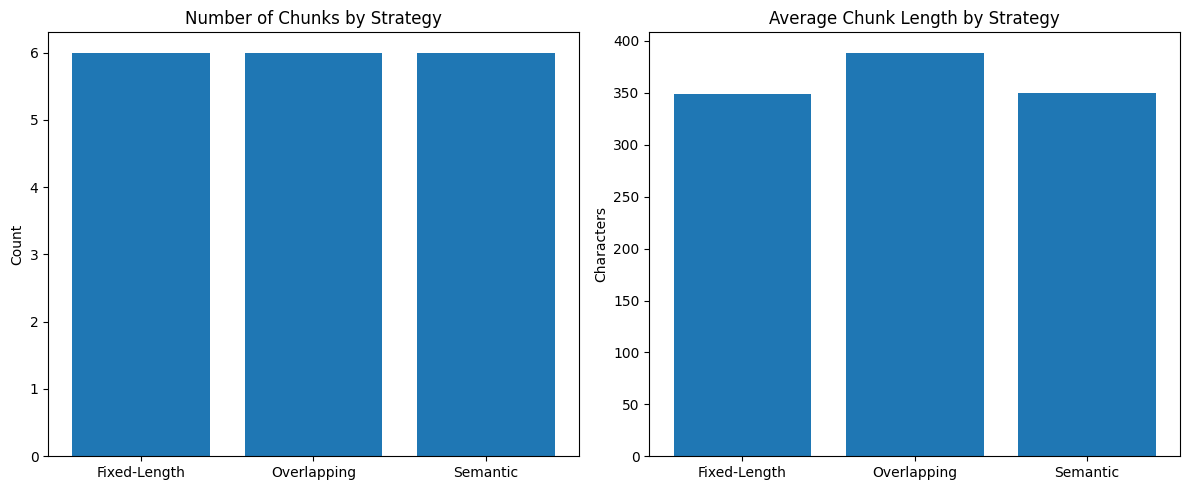

In [10]:
# ============================================
# STEP 7: Compare Chunking Strategies
# ============================================
#
# WHAT WE'RE DOING: Comparing all three chunking strategies side by side.
# WHY THIS MATTERS: Seeing the differences helps you choose the right strategy for your documents.
# WHAT YOU'LL SEE: A table and two bar charts comparing chunk counts and average lengths.
# ============================================
chunking_comparison = pd.DataFrame({
    'Strategy': ['Fixed-Length', 'Overlapping', 'Semantic'],
    'Number of Chunks': [len(chunks_fixed), len(chunks_overlap), len(chunks_semantic)],
    'Average Chunk Length': [
        sum(len(chunk.text) for chunk in chunks_fixed) / len(chunks_fixed),
        sum(len(chunk.text) for chunk in chunks_overlap) / len(chunks_overlap),
        sum(len(chunk.text) for chunk in chunks_semantic) / len(chunks_semantic)
    ]
})

display(chunking_comparison)

# Visualize the comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(chunking_comparison['Strategy'], chunking_comparison['Number of Chunks'])
plt.title('Number of Chunks by Strategy')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.bar(chunking_comparison['Strategy'], chunking_comparison['Average Chunk Length'])
plt.title('Average Chunk Length by Strategy')
plt.ylabel('Characters')

plt.tight_layout()
plt.show()

## 3. Exploring Different Embedding Models

Embeddings convert text into numerical vectors. Let's explore different embedding models:

### 3.1 Hugging Face Embeddings

In [11]:
# ============================================
# STEP 8: Test HuggingFace Embedding Models
# ============================================
#
# WHAT WE'RE DOING: Testing two different embedding models to see how they convert text to numbers.
# WHY THIS MATTERS: Different models produce different quality embeddings — bigger isn't always better.
# WHAT YOU'LL SEE: A table showing each model's dimensions (how many numbers it uses) and speed.
# ============================================
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize a list to store results
embedding_results = []

# Test different HuggingFace embedding models
hf_models = [
    "sentence-transformers/all-MiniLM-L6-v2",  # Small, fast model (384 dimensions)
    "sentence-transformers/all-mpnet-base-v2",  # More powerful (768 dimensions)
]

for model_name in hf_models:
    start_time = time.time()

    embed_model = HuggingFaceEmbedding(model_name=model_name)

    # Generate an embedding for a test sentence
    test_text = "Embeddings are numerical representations of text in vector space."
    embedding = embed_model.get_text_embedding(test_text)

    end_time = time.time()

    embedding_results.append({
        'Model': model_name,
        'Dimensions': len(embedding),
        'Generation Time (s)': end_time - start_time
    })

# Display results
embedding_df = pd.DataFrame(embedding_results)
display(embedding_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,Model,Dimensions,Generation Time (s)
0,sentence-transformers/all-MiniLM-L6-v2,384,1.650252
1,sentence-transformers/all-mpnet-base-v2,768,7.024433


### 3.2 OpenAI Embeddings (Optional)

If you have an OpenAI API key, you can try their embeddings:

In [ ]:
# Uncomment if you have an OpenAI API key
'''
from llama_index.embeddings.openai import OpenAIEmbedding

start_time = time.time()

openai_embed_model = OpenAIEmbedding(model="text-embedding-3-small")
openai_embedding = openai_embed_model.get_text_embedding(test_text)

end_time = time.time()

embedding_results.append({
    'Model': 'OpenAI text-embedding-3-small',
    'Dimensions': len(openai_embedding),
    'Generation Time (s)': end_time - start_time
})

# Update results dataframe
embedding_df = pd.DataFrame(embedding_results)
display(embedding_df)
'''

'\nfrom llama_index.embeddings.openai import OpenAIEmbedding\n\nstart_time = time.time()\n\nopenai_embed_model = OpenAIEmbedding(model="text-embedding-3-small")\nopenai_embedding = openai_embed_model.get_text_embedding(test_text)\n\nend_time = time.time()\n\nembedding_results.append({\n    \'Model\': \'OpenAI text-embedding-3-small\',\n    \'Dimensions\': len(openai_embedding),\n    \'Generation Time (s)\': end_time - start_time\n})\n\n# Update results dataframe\nembedding_df = pd.DataFrame(embedding_results)\ndisplay(embedding_df)\n'

### 3.3 Visualizing Embedding Similarity

Let's visualize how different texts are related in embedding space:

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

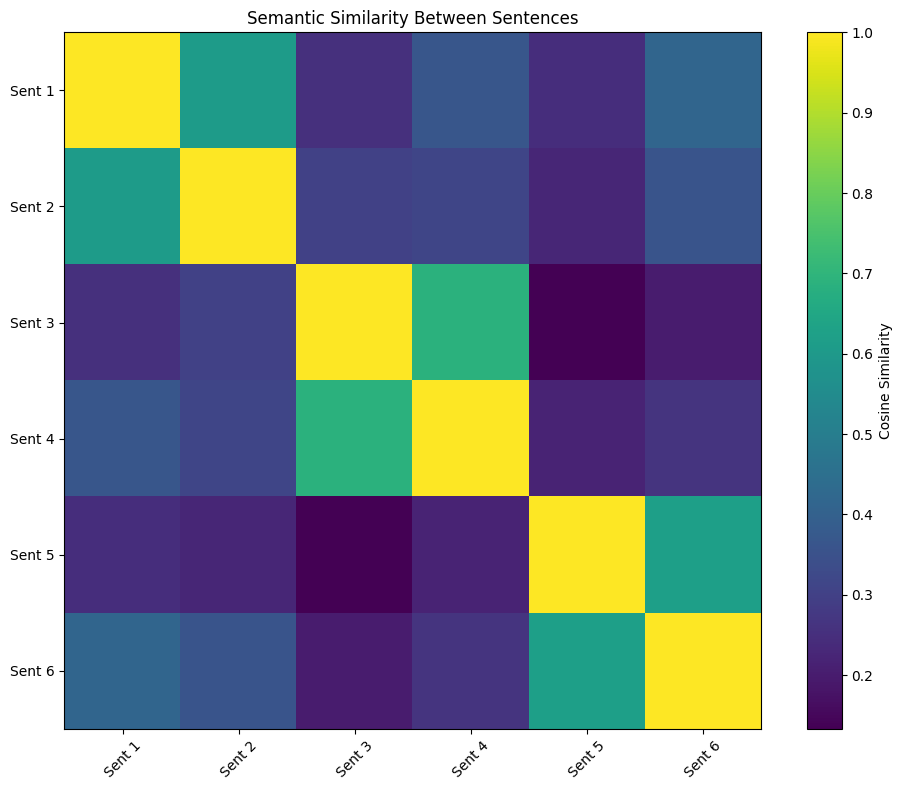

Sentence 1: Neural networks are a powerful machine learning technique.
Sentence 2: Deep learning models have many layers of neurons.
Sentence 3: Embeddings represent words or sentences as vectors.
Sentence 4: Vector representations help computers understand semantics.
Sentence 5: The history of AI begins in the 1950s.
Sentence 6: Artificial intelligence research has evolved over decades.


In [12]:
# ============================================
# STEP 9: Visualize Embedding Similarity
# ============================================
#
# WHAT WE'RE DOING: Creating embeddings for 6 sentences and measuring how similar they are.
# WHY THIS MATTERS: This shows how AI "understands" meaning — similar ideas have similar numbers.
# WHAT YOU'LL SEE: A colored heatmap where brighter colors = more similar sentences.
# ============================================
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define some test sentences
test_sentences = [
    "Neural networks are a powerful machine learning technique.",
    "Deep learning models have many layers of neurons.",
    "Embeddings represent words or sentences as vectors.",
    "Vector representations help computers understand semantics.",
    "The history of AI begins in the 1950s.",
    "Artificial intelligence research has evolved over decades."
]

# Create embeddings for each sentence
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
embeddings = [embed_model.get_text_embedding(sent) for sent in test_sentences]

# Calculate similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Visualize the similarity matrix
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap='viridis')
plt.colorbar(label='Cosine Similarity')
plt.xticks(np.arange(len(test_sentences)), [f"Sent {i+1}" for i in range(len(test_sentences))], rotation=45)
plt.yticks(np.arange(len(test_sentences)), [f"Sent {i+1}" for i in range(len(test_sentences))])
plt.title('Semantic Similarity Between Sentences')
plt.tight_layout()
plt.show()

# Print the sentences for reference
for i, sent in enumerate(test_sentences):
    print(f"Sentence {i+1}: {sent}")

## 4. Building a Vector Store with LlamaIndex

Now, let's combine what we've learned to build a vector database:

In [13]:
# ============================================
# STEP 10: Build a Vector Store
# ============================================
#
# WHAT WE'RE DOING: Building a vector database that stores our document embeddings for fast search.
# WHY THIS MATTERS: Vector databases are the "brain" of any RAG system — they enable semantic search.
# WHAT YOU'LL SEE: "Vector store created successfully!" — your search engine is ready!
# ============================================
from llama_index.core import VectorStoreIndex, StorageContext
from llama_index.vector_stores.chroma import ChromaVectorStore
import chromadb

# Initialize a Chroma client
chroma_client = chromadb.Client()
chroma_collection = chroma_client.get_or_create_collection("semantic_search_demo")

# Create vector store
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vector_store)

# Let's use overlapping chunks for our index
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Create index
index = VectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    embed_model=embed_model
)

print("Vector store created successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vector store created successfully!



## 5. Querying with Gemini

Finally, let's use Gemini to query our vector database:

In [16]:
# ============================================
# STEP 11: Query with Gemini
# ============================================
#
# WHAT WE'RE DOING: Querying our vector database using Gemini to generate AI-powered answers.
# WHY THIS MATTERS: This is the full RAG pipeline in action — retrieve relevant chunks, then generate answers.
# WHAT YOU'LL SEE: For each query: the AI's response plus the source chunks it used.
# ============================================
from llama_index.llms.gemini import Gemini

# Initialize Gemini LLM
llm = Gemini(model="models/gemini-2.0-flash")

# Set up query engine with our custom components
query_engine = index.as_query_engine(
    llm=llm,
    similarity_top_k=2  # Retrieve top 2 most similar chunks
)

# Function to query and display results
def run_query(query_text):
    print(f"Query: {query_text}")
    print("-" * 50)

    # Get response
    response = query_engine.query(query_text)

    print("Response:")
    display(Markdown(response.response))

    print("\nSource Nodes:")
    for i, node in enumerate(response.source_nodes):
        print(f"\nSource {i+1} (Score: {node.score:.4f}):")
        print("-" * 40)
        print(node.text)

    return response

# Try different queries
queries = [
    "How did neural networks develop over time?",
    "What are embeddings and how are they used?",
    "Explain the history of artificial intelligence."
]

# Run each query
for query in queries:
    run_query(query)
    print("\n" + "="*80 + "\n")

/tmp/ipykernel_2046/1077886538.py:12: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  llm = Gemini(model="models/gemini-2.0-flash")


Query: How did neural networks develop over time?
--------------------------------------------------


TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 49.658106859s.

## 6. Interactive Experiments

This section provides instructions and examples for hands-on experimentation with chunking and embedding techniques. Try these experiments to deepen your understanding.

### Experiment 1: Testing Different Chunking Parameters

Try modifying the chunking parameters to see how they affect the results:

In [17]:
# ============================================
# EXPERIMENT 1: Try different chunk sizes and see how it affects results.
# ============================================
#
# WHAT WE'RE DOING: Comparing small (100), medium (300), and large (500) token chunks.
# WHY THIS MATTERS: Chunk size is one of the most important settings in a RAG system.
# WHAT YOU'LL SEE: Chunk counts and sample text from each strategy.
# ============================================

# Example code to experiment with:
from llama_index.core.node_parser import SentenceSplitter

# Example 1: Small chunks, no overlap
splitter_small = SentenceSplitter(chunk_size=100, chunk_overlap=0)
chunks_small = splitter_small.get_nodes_from_documents(documents)
print(f"Small chunks: Created {len(chunks_small)} chunks")

# Example 2: Medium chunks with overlap
splitter_medium = SentenceSplitter(chunk_size=300, chunk_overlap=30)
chunks_medium = splitter_medium.get_nodes_from_documents(documents)
print(f"Medium chunks: Created {len(chunks_medium)} chunks")

# Example 3: Large chunks with larger overlap
splitter_large = SentenceSplitter(chunk_size=500, chunk_overlap=100)
chunks_large = splitter_large.get_nodes_from_documents(documents)
print(f"Large chunks: Created {len(chunks_large)} chunks")

# To inspect chunks, print a few examples:
def inspect_chunks(chunks, name):
    print(f"\n--- First chunk from {name} ---")
    print(chunks[0].text[:200] + "...")  # Show first 200 chars of first chunk
    if len(chunks) > 1:
        print(f"\n--- Second chunk from {name} ---")
        print(chunks[1].text[:200] + "...")  # Show first 200 chars of second chunk

# Inspect samples from each chunking strategy
inspect_chunks(chunks_small, "small chunks")
inspect_chunks(chunks_medium, "medium chunks")
inspect_chunks(chunks_large, "large chunks")

Small chunks: Created 6 chunks
Medium chunks: Created 3 chunks
Large chunks: Created 3 chunks

--- First chunk from small chunks ---
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods ...

--- Second chunk from small chunks ---
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.
These mode...

--- First chunk from medium chunks ---
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods ...

--- Second chunk from medium chunks ---
Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar w

**Questions to consider:**
- How does changing chunk size affect the total number of chunks?
- What happens to semantic coherence as you decrease chunk size?
- How does overlap help maintain context between chunks?


### Experiment 2: Comparing Embedding Similarities

Explore how different texts are related in embedding space:

In [18]:
# ============================================
# EXPERIMENT 2: Compare how similar different sentences are using embeddings.
# ============================================
#
# WHAT WE'RE DOING: Measuring cosine similarity between pairs of sentences.
# WHY THIS MATTERS: Understanding similarity scores helps you tune your search system.
# WHAT YOU'LL SEE: Similarity scores (0 to 1) for each pair — higher = more similar.
# ============================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize embedding model
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Define pairs of sentences to compare
sentence_pairs = [
    # Similar topic, similar wording
    ("Neural networks process data through interconnected nodes.",
     "Neural networks analyze information using connected neurons."),

    # Similar topic, different wording
    ("Embeddings transform text into vectors.",
     "Vector representations capture the semantic meaning of words."),

    # Different topics
    ("Neural networks are used in image recognition.",
     "Embeddings are used for semantic search."),

    # Try your own pairs!
    # ("Your custom sentence 1", "Your custom sentence 2")
]

# Calculate similarity for each pair
for i, (sent1, sent2) in enumerate(sentence_pairs):
    # Get embeddings
    emb1 = embed_model.get_text_embedding(sent1)
    emb2 = embed_model.get_text_embedding(sent2)

    # Calculate similarity
    similarity = cosine_similarity([emb1], [emb2])[0][0]

    # Print results
    print(f"\nPair {i+1}:")
    print(f"Sentence 1: {sent1}")
    print(f"Sentence 2: {sent2}")
    print(f"Similarity Score: {similarity:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Pair 1:
Sentence 1: Neural networks process data through interconnected nodes.
Sentence 2: Neural networks analyze information using connected neurons.
Similarity Score: 0.6275

Pair 2:
Sentence 1: Embeddings transform text into vectors.
Sentence 2: Vector representations capture the semantic meaning of words.
Similarity Score: 0.6206

Pair 3:
Sentence 1: Neural networks are used in image recognition.
Sentence 2: Embeddings are used for semantic search.
Similarity Score: 0.3161


**Questions to consider:**
- What similarity threshold would you use to consider two sentences as related?
- How does word choice affect similarity even when the meaning is similar?
- What happens if you try different embedding models?



### Experiment 3: Custom Querying with Different Parameters

Modify query parameters to see how they affect retrieval results:

In [19]:
# ============================================
# EXPERIMENT 3: Test how the top_k parameter affects search results.
# ============================================
#
# WHAT WE'RE DOING: Setting up queries to test with different numbers of retrieved chunks.
# WHY THIS MATTERS: Retrieving too few chunks may miss info; too many adds noise.
# WHAT YOU'LL SEE: No output yet — this sets up the test function.
# ============================================

from llama_index.llms.gemini import Gemini

# Initialize Gemini LLM
llm = Gemini(model="models/gemini-2.0-flash")

# Sample queries to test
test_queries = [
    "What are neural networks?",
    "How have embeddings evolved over time?",
    "Describe the history of AI development.",
    # Add your own queries here!
]

# Try different top_k values
top_k_values = [1, 2, 4]

# Function to run a query with a specific top_k
def test_query(query_text, top_k):
    # Set up query engine
    query_engine = index.as_query_engine(
        llm=llm,
        similarity_top_k=top_k
    )

    # Get response
    response = query_engine.query(query_text)

    print(f"\nQuery: {query_text}")
    print(f"Using top_k = {top_k}")
    print("-" * 50)
    print(f"Response: {response.response[:200]}...")  # First 200 chars

    print(f"\nRetrieved {len(response.source_nodes)} source nodes:")
    for i, node in enumerate(response.source_nodes):
        print(f"  Source {i+1} (Score: {node.score:.4f}): {node.text[:100]}...")

    return response

/tmp/ipykernel_2046/1855539533.py:13: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  llm = Gemini(model="models/gemini-2.0-flash")


In [20]:
# ============================================
# Running Experiment 3 with top_k=2 (retrieve the 2 most similar chunks).
# WHAT YOU'LL SEE: The query, response, and which source chunks were used.
# ============================================

# Example usage:
# Choose a query from test_queries and a top_k value to experiment with
test_query(test_queries[0], top_k=2)

TooManyRequests: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 49.816159935s.

**Questions to consider:**
- How does increasing top_k affect response quality?
- Is there a point where adding more chunks decreases answer quality?
- How do different chunking strategies affect the retrieval results?

### Experiment 4: Comparing Different Embedding Models

Compare the performance of different embedding models:

In [21]:
# ============================================
# EXPERIMENT 4: Compare different embedding models side by side.
# ============================================
#
# WHAT WE'RE DOING: Generating embeddings with two models and comparing speed + dimensions.
# WHY THIS MATTERS: Model choice affects both quality and performance of your search system.
# WHAT YOU'LL SEE: Each model's dimensions, first 5 embedding values, and generation time.
# ============================================

from llama_index.embeddings.huggingface import HuggingFaceEmbedding
import time

# Define embedding models to test
embedding_models = [
    "sentence-transformers/all-MiniLM-L6-v2",  # Small, fast model (384 dimensions)
    "sentence-transformers/all-mpnet-base-v2",  # More powerful (768 dimensions)
    # Add other models if desired
]

# Test text
test_text = "Embeddings transform words into numerical vectors that capture meaning."

# Compare models
for model_name in embedding_models:
    print(f"\nTesting model: {model_name}")

    # Time the embedding generation
    start_time = time.time()
    embed_model = HuggingFaceEmbedding(model_name=model_name)
    embedding = embed_model.get_text_embedding(test_text)
    end_time = time.time()

    # Print results
    print(f"Dimensions: {len(embedding)}")
    print(f"First 5 values: {embedding[:5]}")
    print(f"Generation time: {end_time - start_time:.4f} seconds")

# Optional: Create a simple index with different embedding models and compare
# the retrieval results for the same query


Testing model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Dimensions: 384
First 5 values: [-0.0011336231837049127, -0.03034723550081253, 0.051215894520282745, -0.03696787729859352, 0.016310786828398705]
Generation time: 1.5130 seconds

Testing model: sentence-transformers/all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Dimensions: 768
First 5 values: [-0.041781578212976456, 0.061772774904966354, -0.01206276472657919, 0.04535938426852226, 0.022207098081707954]
Generation time: 1.8246 seconds


**Questions to consider:**
- How does embedding dimension affect performance and quality?
- Is the additional computation time for larger models worth the quality improvement?
- Which model would you choose for a production application and why?

## Key Takeaways

1. **Chunking Strategies**:
   - Fixed-length chunking is simple but may break semantic coherence
   - Overlapping chunks help maintain context across boundaries
   - Semantic chunking preserves meaning-based segments but is more resource-intensive

2. **Embedding Models**:
   - Different models offer varying dimensions and performance characteristics
   - Larger models typically provide better semantic understanding but are slower
   - Domain-specific models can outperform generic ones for specialized tasks

3. **Retrieval Performance**:
   - The choice of chunking and embedding strategy significantly impacts retrieval quality
   - Tuning parameters like chunk size, overlap, and top_k affects results
   - The best approach depends on your specific documents and use case

4. **LlamaIndex + Gemini Integration**:
   - Combining LlamaIndex's retrieval capabilities with Gemini's language capabilities creates powerful RAG systems
   - This modular approach lets you optimize each component separately

### Next Steps:

- Try different chunking strategies on your own documents
- Experiment with domain-specific embedding models
- Explore advanced retrievers like hierarchical or hybrid retrievers
- Fine-tune the system by adjusting response synthesis settings